In [1]:
import numpy as np
from IQAEBinom import IQAEBinom
import matplotlib.pyplot as plt
import pickle
from BiasCorrection import BiasExact
import datetime

In [2]:
epsilon = 0.001
nEstim = 10000
alpha = 0.05
nShotUnit = 1

In [3]:
p = np.pi / 5 + 0.001

In [4]:
alpha = 0.05 / nEstim
results = np.array([])

for i in range(nEstim):
    result = IQAEBinom(p, epsilon, alpha, nShotUnit, confint_method="chernoff")
    results = np.append(results, result)

In [5]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue=piOver5+0.001_epsilon0001_alpha005.dat", 'wb') as f:
    pickle.dump(results, f) 

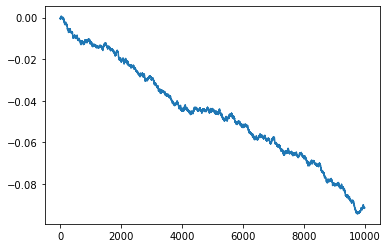

In [6]:
errs = [r["Estimate"] - p for r in results]

ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.show()

In [7]:
print(np.mean(errs))
print(np.std(errs) / np.sqrt(nEstim))

-9.150015148174284e-06
1.6172449354082186e-06


In [8]:
results[0]

{'Estimate': 0.6291540882635879,
 'TotalOracleCalls': 51180,
 'nGrover': [0, 1, 5, 12, 30, 65, 131, 269],
 'nShots': [867, 522, 103, 103, 89, 67, 66, 25],
 'n1s': [557, 81, 37, 59, 33, 31, 37, 6],
 'thetaIntervals': [[0, 1.5707963267948966],
  [0.820553981145302, 1.046924586783186],
  [0.8577776572529469, 0.9990463290616484],
  [0.880627842912262, 0.9421709361643322],
  [0.9022891817863484, 0.9270219961790636],
  [0.9113208461061943, 0.9225648085647162],
  [0.9140837486978872, 0.9197372612750334],
  [0.9150893295937577, 0.917878558351774],
  [0.9150835744222588, 0.917054723397521]],
 'ampSqIntervals': [[0, 1],
  [0.5351268581183247, 0.7497635686406141],
  [0.5721269712164594, 0.7072058697885302],
  [0.5946549837737722, 0.6542166269883526],
  [0.615829163200418, 0.6397376861613613],
  [0.6245957672319998, 0.6354526092352791],
  [0.6272695960621406, 0.6327286437929263],
  [0.6282417975523492, 0.6309357132915404],
  [0.6282362348909906, 0.6301404505220752]]}

(array([0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 5.000e+00, 1.610e+02, 4.380e+02, 4.740e+02,
        1.524e+03, 3.140e+02, 1.082e+03, 3.299e+03, 1.002e+03, 7.610e+02,
        3.770e+02, 2.700e+01, 3.000e+01, 4.800e+01, 4.500e+01, 1.200e+01,
        2.200e+01, 5.000e+00, 1.100e+01, 3.000e+00, 2.100e+01, 5.000e+01,
        5.600e+01, 7.100e+01, 4.500e+01, 3.000e+01, 4.100e+01, 3.300e+01,
        4.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 3.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]),
 array([100., 110., 120., 130., 140., 150., 160., 170., 180., 190., 200.,
        210., 220., 230., 240., 250., 260., 270., 280., 290., 300., 310.,
        320., 330., 340., 350., 360., 370., 380., 390., 400., 410., 420.,
        430., 440., 450., 460., 470.

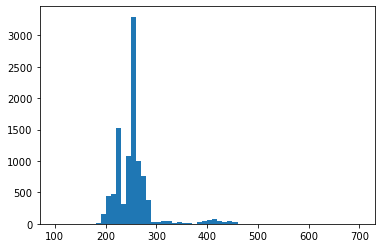

In [9]:
plt.hist([r["nGrover"][-1] for r in results], range=(100,700), bins=60)

(array([1.750e+02, 3.400e+01, 1.220e+02, 7.800e+01, 2.940e+02, 1.066e+03,
        5.750e+02, 8.890e+02, 1.246e+03, 1.204e+03, 1.014e+03, 9.090e+02,
        6.980e+02, 5.670e+02, 3.570e+02, 2.930e+02, 1.660e+02, 1.730e+02,
        5.100e+01, 3.400e+01, 7.000e+00, 1.400e+01, 1.100e+01, 1.100e+01,
        4.000e+00, 5.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 0.000e+00]),
 array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
         55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
        110., 115., 120., 125., 130., 135., 140., 145., 150.]),
 <BarContainer object of 30 artists>)

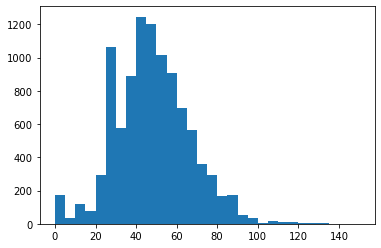

In [10]:
plt.hist([r["nShots"][-1] for r in results], range=(0,150), bins=30)

(array([1.770e+02, 1.920e+02, 4.470e+02, 8.070e+02, 2.210e+02, 1.260e+02,
        7.500e+01, 7.700e+01, 2.600e+02, 1.175e+03, 1.310e+03, 1.356e+03,
        1.062e+03, 5.530e+02, 3.720e+02, 3.140e+02, 2.000e+02, 1.950e+02,
        1.930e+02, 1.810e+02, 1.470e+02, 9.900e+01, 8.000e+01, 7.400e+01,
        5.300e+01, 5.100e+01, 4.100e+01, 3.600e+01, 2.200e+01, 2.200e+01,
        1.800e+01, 2.600e+01, 1.300e+01, 4.000e+00, 0.000e+00, 2.000e+00,
        6.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 2.000e+00, 2.000e+00,
        1.000e+00, 0.000e+00, 3.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00]),
 array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
         22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
         44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
         66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
         88.,  90.,  92.,  94.,  96.,  98., 100.]),
 <BarContainer object of 50 

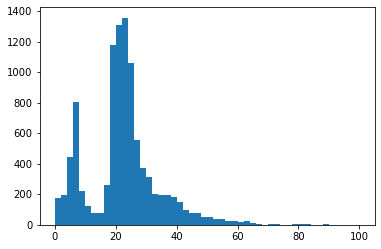

In [11]:
plt.hist([r["n1s"][-1] for r in results], range=(0,100), bins=50)

final p1はunbiasedになってるか？

(array([  0.,   3.,  16.,  27.,  53.,  67., 105.,  99., 198., 118., 228.,
        205., 360., 173., 278., 311., 356., 415., 409., 431., 442., 390.,
        341., 361., 211., 783., 338., 379., 337., 313., 472., 310., 260.,
        203., 141., 115.,  86., 164.,  70.,  89.,  76.,  75.,  42.,  45.,
         38.,  40.,  17.,   6.,   2.,   2.]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 <BarContainer object of 50 artists>)

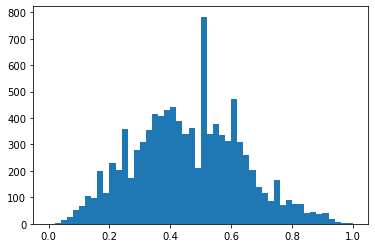

In [12]:
plt.hist([r["n1s"][-1] / r["nShots"][-1] for r in results], range=(0,1), bins=50)

In [13]:
thetaTrue = np.arcsin(np.sqrt(p))
p1FinalErr = [r["n1s"][-1] / r["nShots"][-1] - np.sin((2 * r["nGrover"][-1] + 1) * thetaTrue) ** 2 for r in results]

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,   1.,   0.,
          1.,   0.,   1.,   0.,   1.,   0.,   0.,   4.,   5.,   2.,   0.,
          3.,   5.,  11.,  10.,  17.,  20.,  34.,  43.,  29.,  51.,  72.,
        105.,  88., 137., 114., 205., 238., 303., 295., 322., 366., 526.,
        464., 494., 502., 569., 606., 533., 504., 417., 425., 340., 424.,
        251., 300., 209., 131., 139., 140.,  81.,  36.,  84.,  33.,  96.,
         24.,  17.,  63.,  17.,   8.,   5.,  11.,   4.,   0.,   1.,  29.,
         27.,   3.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([-7.00000000e-01, -6.90000000e-01, -6.80000000e

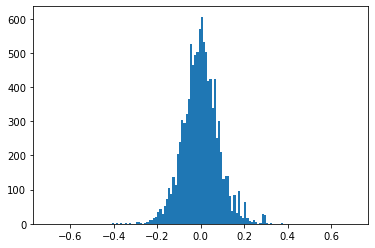

In [14]:
plt.hist(p1FinalErr, range=(-0.7, 0.7), bins=140)

In [15]:
print(np.mean(p1FinalErr))
print(np.std(p1FinalErr) / np.sqrt(len(p1FinalErr)))

0.0004084097849113157
0.0008216920306058931


errorの分布

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,   2.,   2.,
          1.,   2.,   2.,   6.,   6.,   9.,  25.,  12.,  39.,  42.,  63.,
         81.,  66.,  91.,  95., 162., 131., 298., 207., 316., 440., 350.,
        291., 494., 526., 468., 502., 544., 539., 545., 485., 466., 362.,
        368., 347., 252., 184., 214., 158., 138., 149.,  98.,  62.,  90.,
         40.,  44.,  48.,  46.,  14.,  31.,   7.,   3.,  14.,   2.,  10.,
          1.,   5.,   0.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([-1.0e-03, -9.8e-04, -9.6e-04, -9.4e-04, -9.2e-04, -9.0e-04,
        -8.8e-04, -8.6e-04, -8.4e-04, -8.2e-04, -8.0e-04, -7.8e-04,
        -7.6e-04, -7.4e-04, -7.2e-04, -7.0e-04, -6.8e-04, -6.6e-04,
        -6.4e-04, -6.2e-04, -6.0e-04, -5.8e-04, -5.6e-04, -5.4e-04,
        -5.2e-04, -5.0e-04, -4.8e-04, -4.6e-04

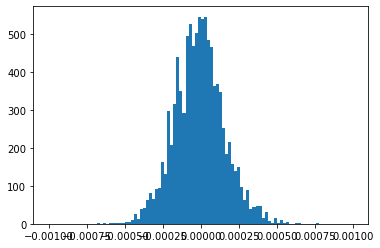

In [16]:
plt.hist(errs, range=(-0.001,0.001), bins=100)